# Kinematical X-ray Scattering

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dschick/udkm1Dsim/blob/develop/examples/05-xrays/00-kinematical_xray.ipynb)

In this example static X-ray simulations are carried out employing the kinematical X-ray scattering formalism.

## Setup

Do all necessary imports and settings.

In [1]:
try:
    import udkm1Dsim as ud
except ImportError:
    %pip install udkm1Dsim[parallel]
    import udkm1Dsim as ud

u = ud.u  # import the pint unit registry from udkm1Dsim
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
u.setup_matplotlib()  # use matplotlib with pint units

## Structure

Refer to the [structure example](#example_structure) for more details.

In [2]:
O = ud.Atom('O')
Ti = ud.Atom('Ti')
Sr = ud.Atom('Sr')
Ru = ud.Atom('Ru')
Pb = ud.Atom('Pb')
Zr = ud.Atom('Zr')

In [3]:
# c-axis lattice constants of the two layers
c_STO_sub = 3.905*u.angstrom
c_SRO = 3.94897*u.angstrom
# sound velocities [nm/ps] of the two layers
sv_SRO = 6.312*u.nm/u.ps
sv_STO = 7.800*u.nm/u.ps

# SRO layer
prop_SRO = {}
prop_SRO['a_axis'] = c_STO_sub  # aAxis
prop_SRO['b_axis'] = c_STO_sub  # bAxis
prop_SRO['deb_wal_fac'] = 0  # Debye-Waller factor
prop_SRO['sound_vel'] = sv_SRO  # sound velocity
prop_SRO['opt_ref_index'] = 2.44+4.32j
prop_SRO['therm_cond'] = 5.72*u.W/(u.m*u.K)  # heat conductivity
prop_SRO['lin_therm_exp'] = 1.03e-5  # linear thermal expansion
prop_SRO['heat_capacity'] = '455.2 + 0.112*T - 2.1935e6/T**2'  # [J/kg K]

SRO = ud.UnitCell('SRO', 'Strontium Ruthenate', c_SRO, **prop_SRO)
SRO.add_atom(O, 0)
SRO.add_atom(Sr, 0)
SRO.add_atom(O, 0.5)
SRO.add_atom(O, 0.5)
SRO.add_atom(Ru, 0.5)

# STO substrate
prop_STO_sub = {}
prop_STO_sub['a_axis'] = c_STO_sub  # aAxis
prop_STO_sub['b_axis'] = c_STO_sub  # bAxis
prop_STO_sub['deb_wal_fac'] = 0  # Debye-Waller factor
prop_STO_sub['sound_vel'] = sv_STO  # sound velocity
prop_STO_sub['opt_ref_index'] = 2.1+0j
prop_STO_sub['therm_cond'] = 12*u.W/(u.m*u.K)  # heat conductivity
prop_STO_sub['lin_therm_exp'] = 1e-5  # linear thermal expansion
prop_STO_sub['heat_capacity'] = '733.73 + 0.0248*T - 6.531e6/T**2'  # [J/kg K]

STO_sub = ud.UnitCell('STOsub', 'Strontium Titanate Substrate',
                      c_STO_sub, **prop_STO_sub)
STO_sub.add_atom(O, 0)
STO_sub.add_atom(Sr, 0)
STO_sub.add_atom(O, 0.5)
STO_sub.add_atom(O, 0.5)
STO_sub.add_atom(Ti, 0.5)

In [13]:
S = ud.Structure('Single Layer')
S.add_sub_structure(SRO, 200)  # add 100 layers of SRO to sample
S.add_sub_structure(STO_sub, 1000000)  # add 1000 layers of dynamic STO substrate

substrate = ud.Structure('Static Substrate')
# add 1000000 layers of static STO substrate
substrate.add_sub_structure(STO_sub, 1000000)
#S.add_substrate(substrate)

## Initialize kinematical X-ray simulation

The {py:class}`XrayKin <udkm1Dsim.simulations.xrays.XrayKin>` class requires a {py:class}`Structure <udkm1Dsim.structures.structure.Structure>` object and a boolean `force_recalc` in order overwrite previous simulation results.

These results are saved in the `cache_dir` when `save_data` is enabled.
Printing simulation messages can be en-/disabled using `disp_messages` and progress bars can using the boolean switch `progress_bar`.

In [14]:
kin = ud.XrayKin(S, True)
kin.disp_messages = True
kin.save_data = False

incoming polarizations set to: sigma
analyzer polarizations set to: unpolarized


## Homogeneous X-ray scattering

For the case of homogeneously strained samples, the kinematical X-ray scattering simulations can be greatly simplified, which saves a lot of computational time.

### $q_z$-scan

The {py:class}`XrayKin <udkm1Dsim.simulations.xrays.XrayKin>`object requires an `energy` and scattering vector `qz` to run the simulations.  
Both parameters can be arrays and the resulting reflectivity has a first dimension for the photon energy and the a second for the scattering vector.

In [15]:
kin.energy = 8047*u.eV  # set two photon energies
kin.qz = np.r_[3.1:3.3:0.00001]/u.angstrom  # qz range

R_hom, A = kin.homogeneous_reflectivity()  # this is the actual calculation

Calculating _homogenous_reflectivity_ ...
Elapsed time for _homogenous_reflectivity_: 0.016962 s


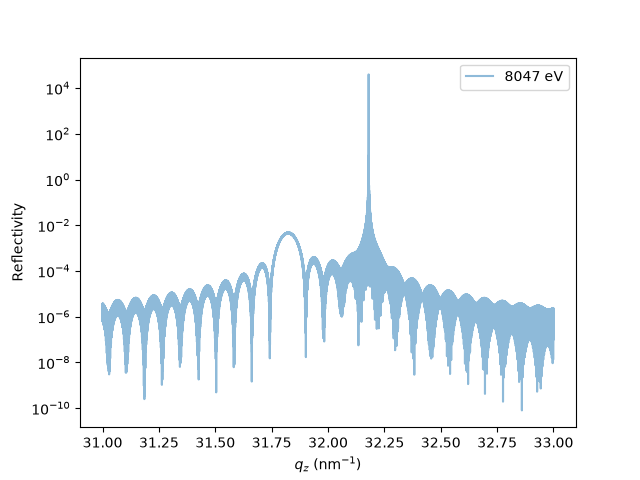

In [16]:
plt.figure()
plt.semilogy(kin.qz[0, :], R_hom[0, :], label='{}'.format(kin.energy[0]), alpha=0.5)
plt.ylabel('Reflectivity')
plt.xlabel('$q_z$ (nm$^{-1}$)')
plt.legend()
plt.show()

### Post-Processing

All result can be convoluted with an arbitrary function handle, which e.g. mimics the instrumental resolution.

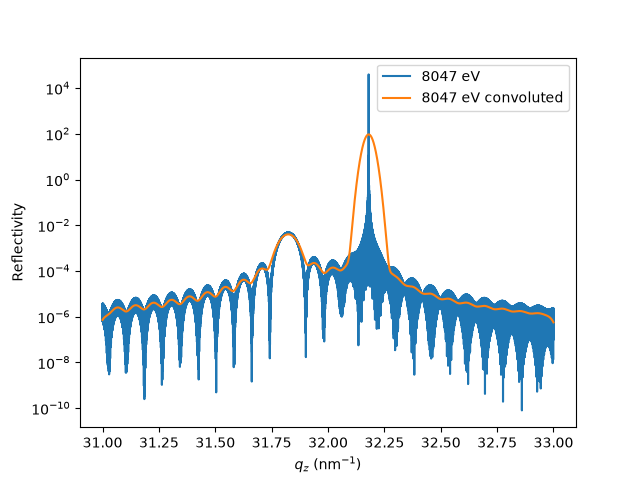

In [17]:
FWHM = 0.004/1e-10  # Angstrom
sigma = FWHM/2.3548

handle = lambda x: np.exp(-((x)/sigma)**2/2)
y_conv = kin.conv_with_function(R_hom[0, :], kin._qz[0, :], handle)

plt.figure()
plt.semilogy(kin.qz[0, :], R_hom[0, :], label='{}'.format(kin.energy[0]))
plt.semilogy(kin.qz[0, :], y_conv, label='{} convoluted'.format(kin.energy[0]))
plt.ylabel('Reflectivity')
plt.xlabel('$q_z$ (nm$^{-1}$)')
plt.legend()
plt.show()

## Widget

The :py:meth:`udkm1Dsim.simulations.xrays.XrayKin.homogeneous_reflectivity()` method is so fast, it is possible to build some fancy widgets, e.g. for visual data fitting.

:::{attention}
In order to get the widget to work in Jupyter, you should install the following packages which are not a dependency of the **udkm1Dsim** toolbox

    > pip install ipympl ipywidgets

or

    > conda install ipympl ipywidgets
:::

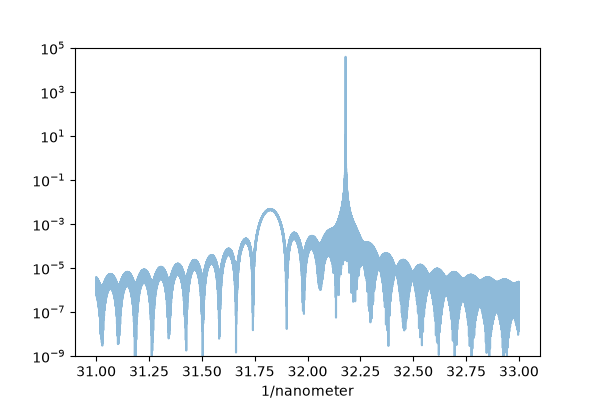

In [18]:
%matplotlib widget

from ipywidgets import FloatSlider, VBox
from IPython.display import display

kin.disp_messages = False
R_hom, A = kin.homogeneous_reflectivity()

fig, ax = plt.subplots(figsize=(6,4))
line = ax.semilogy(kin.qz[0, :], R_hom[0, :],
                label='{}'.format(kin.energy[0]), alpha=0.5)[0]
# plt.ylabel('Reflectivity')
# plt.xlabel('$q_z$ (nm$^{-1}$)')
ax.set_ylim(1e-9, 1e5)
# plt.legend()
# plt.show()


SRO_caxis = FloatSlider(value=3.94897, min=2, max=5, step=0.001, 
    description='SRO c-axis')
FWHM = FloatSlider(value=0.004/1e-10, min=0.001/1e-10, max=0.010/1e-10, 
    description='FWHM')

def update(change):
    SRO.c_axis = SRO_caxis.value*u.angstrom
    R_hom, A = kin.homogeneous_reflectivity()
    sigma = FWHM.value/2.3548
    handle = lambda x: np.exp(-((x)/sigma)**2/2)
    y_conv = kin.conv_with_function(R_hom[0, :], kin._qz[0, :], handle)
    line.set_ydata(y_conv)
    fig.canvas.draw_idle()

SRO_caxis.observe(update, names="value")
FWHM.observe(update, names="value")
# freq.observe(update, names="value")

display(VBox([SRO_caxis, FWHM]))